In [7]:
import numpy as np
import pandas as pd
import matplotlib
# matplotlib.use('TkAgg')
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns


# 设置绘图字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

### 1. 数据读取与基础分析 ###
# 读取混凝土数据
file_path = "D:\\入学材料\\研一\\神经网络及其应用\\Assignment1\\Concrete_Data_Yeh.csv"
concrete_data = pd.read_csv(file_path)

print("--- 数据集前五行 ---")
print(concrete_data.head())

--- 数据集前五行 ---
   cement   slag  flyash  water  superplasticizer  coarseaggregate  \
0   540.0    0.0     0.0  162.0               2.5           1040.0   
1   540.0    0.0     0.0  162.0               2.5           1055.0   
2   332.5  142.5     0.0  228.0               0.0            932.0   
3   332.5  142.5     0.0  228.0               0.0            932.0   
4   198.6  132.4     0.0  192.0               0.0            978.4   

   fineaggregate  age  csMPa  
0          676.0   28  79.99  
1          676.0   28  61.89  
2          594.0  270  40.27  
3          594.0  365  41.05  
4          825.5  360  44.30  


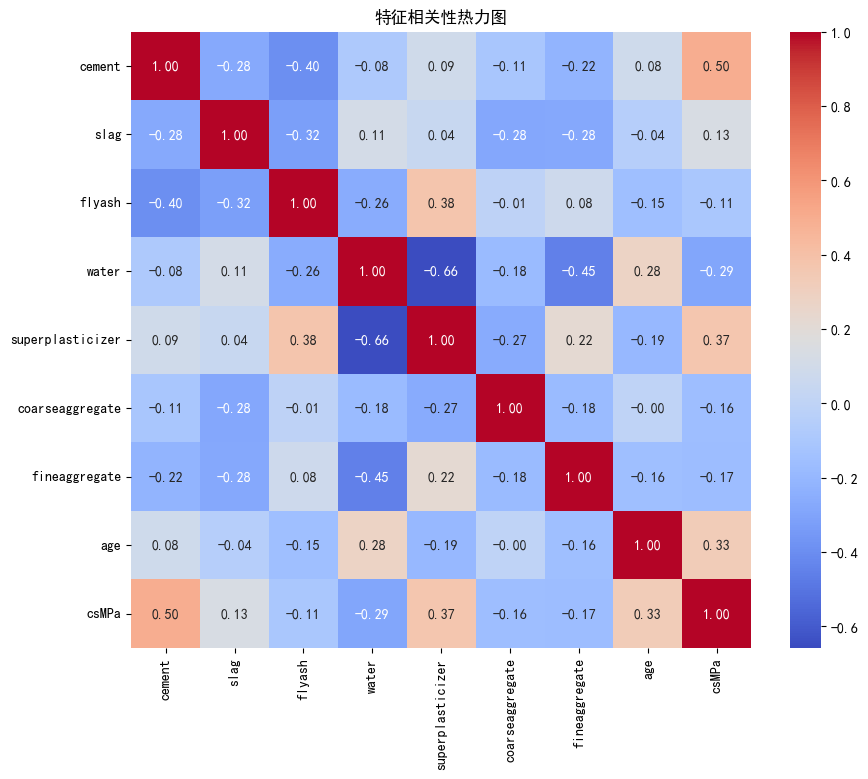


--- 特征与强度(csMPa)的相关性排序 ---
csMPa               1.000000
cement              0.497832
superplasticizer    0.366079
age                 0.328873
slag                0.134829
flyash             -0.105755
coarseaggregate    -0.164935
fineaggregate      -0.167241
water              -0.289633
Name: csMPa, dtype: float64


In [8]:
### 2. 相关性分析 (Methods - Correlation Analysis) ###
# 计算相关矩阵
correlation_matrix = concrete_data.corr()

# 可视化热力图
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('特征相关性热力图')
plt.show()

# 查看与目标变量 csMPa 相关性最高的特征变量
correlation_with_target = correlation_matrix['csMPa'].sort_values(ascending=False)
print("\n--- 特征与强度(csMPa)的相关性排序 ---")
print(correlation_with_target)

In [9]:
### 3. 线性回归模型构建 ###
# 拆分特征和目标变量
# 如果你想尝试剔除低相关特征，可以将下面这行改为：
# x = concrete_data[['cement', 'superplasticizer', 'age', 'water']]
x = concrete_data.drop(columns='csMPa', axis=1)
y = concrete_data['csMPa']

# 数据分割：按照作业要求，前80%训练，后20%测试
# 注意：线性回归通常使用随机切分(random_state)来获得更稳健的结果
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# 创建并训练模型
model = LinearRegression()
model.fit(x_train, y_train)

# 模型预测
y_pred = model.predict(x_test)

In [4]:
### 4. 预测效果评价 (Evaluation) ###
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)  # 均方根误差
r2 = r2_score(y_test, y_pred) # 决定系数

print("\n" + "="*40)
print("       线性回归模型预测效果报告")
print("="*40)
print(f"1. 均方误差 (MSE):       {mse:.2f}")
print(f"2. 均方根误差 (RMSE):    {rmse:.2f} MPa")
print(f"3. 决定系数 (R^2):       {r2:.4f}")
print("-" * 40)

# 自动评价逻辑
if r2 > 0.7:
    eval_text = "拟合效果良好，模型解释了大部分数据方差。"
elif r2 > 0.5:
    eval_text = "拟合效果一般，线性模型抓住了基本趋势，但存在非线性误差。"
else:
    eval_text = "拟合效果较差，建议检查特征选择或改用神经网络。"

print(f"综合评价：{eval_text}")
print(f"物理意义：平均预测偏差约为 {rmse:.2f} MPa。")
print("="*40)


       线性回归模型预测效果报告
1. 均方误差 (MSE):       95.97
2. 均方根误差 (RMSE):    9.80 MPa
3. 决定系数 (R^2):       0.6276
----------------------------------------
综合评价：拟合效果一般，线性模型抓住了基本趋势，但存在非线性误差。
物理意义：平均预测偏差约为 9.80 MPa。


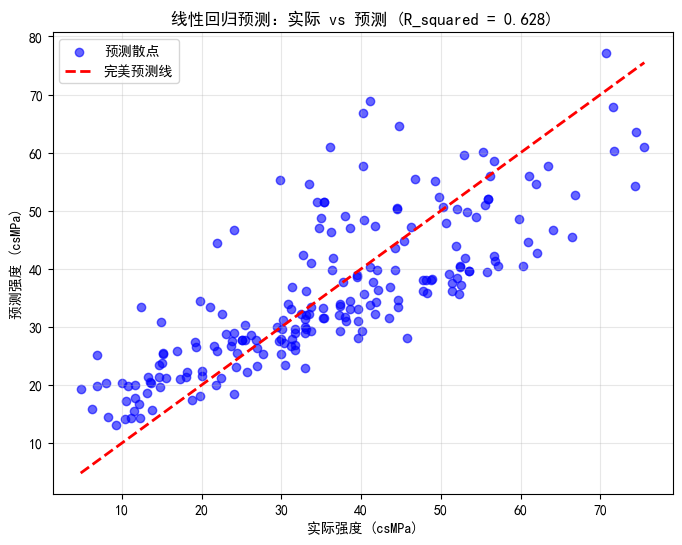

In [10]:
### 5. 可视化分析 ###
# 绘制 实际值 vs 预测值 散点图
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='blue', label='预测散点')

# 绘制完美预测线（红虚线）
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='完美预测线')

plt.xlabel('实际强度 (csMPa)')
plt.ylabel('预测强度 (csMPa)')
plt.title(f'线性回归预测：实际 vs 预测 (R_squared = {r2:.3f})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()